# Seasonal Agriculture Performance Analysis

## Major Data Analytics Project

**Student Name: ** CHILAKA SUPRIYA

**AICTE STU ID: ** STU6a50ff438a13b1783693123

### Domain
Agriculture

### Project Theme
Seasonal Agriculture Performance

### Tools
Python, Pandas, NumPy, Matplotlib, Seaborn, SciPy

### Project Goal
Investigate how agricultural performance varies across seasons
and identify meaningful patterns, trends, relationships and
differences in the available data.

### Project Type
Data Analytics

No Machine Learning or dashboard development is used in this project.

# Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.

The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

# Problem Objective

The objective of this project is to analyze the given agricultural dataset to understand how agricultural performance varies across different seasons and to identify meaningful patterns, trends, relationships and differences in the data.

The analysis focuses on examining seasonal performance, environmental conditions, farming practices, resource usage, production and economic outcomes using appropriate data analytics, statistical and visualization techniques.

#1. IMPORT LIBRARIES

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


#2. LOAD DATASET

In [51]:
file_path = "/content/seasonal_agriculture_performance_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")

Dataset loaded successfully!


#3. TOP 5 ROWS

In [52]:
print("Top 5 rows of the dataset:")
display(df.head())

Top 5 rows of the dataset:


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


#4. DATASET SHAPE

In [53]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 4000
Number of columns: 28


#5. DATASET STRUCTURE

In [54]:
print("Dataset information:")
df.info()

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha             

#6. COLUMN NAMES

In [55]:
print("Columns in the dataset:\n")

for i, column in enumerate(df.columns, 1):
    print(i, ".", column)

Columns in the dataset:

1 . Farm_ID
2 . State
3 . District
4 . Crop
5 . Season
6 . Farm_Area_Hectares
7 . Rainfall_mm
8 . Avg_Temperature_C
9 . Humidity_pct
10 . Sunlight_Hours_Day
11 . Soil_pH
12 . Soil_Moisture_pct
13 . Nitrogen_kg_ha
14 . Phosphorus_kg_ha
15 . Potassium_kg_ha
16 . Irrigation_Method
17 . Fertilizer_kg_ha
18 . Pesticide_Litre_ha
19 . Seed_Quality_Score
20 . Yield_Tonnes_Ha
21 . Production_Tonnes
22 . Market_Price_INR_Tonne
23 . Total_Cost_INR
24 . Revenue_INR
25 . Profit_INR
26 . Water_Used_m3
27 . Water_Efficiency_t_per_1000m3
28 . Disease_Pest_Risk_pct


#7. DATA TYPES

In [56]:
print("Data types:")
display(df.dtypes.to_frame(name="Data Type"))

Data types:


,Data Type
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


#8. MISSING VALUES

In [57]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values[missing_values > 0])

Missing values in each column:


,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


#9. HANDLE MISSING VALUES

Numerically missing values are handled using the median.



In [58]:
numeric_columns = df.select_dtypes(include=np.number).columns

for column in numeric_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

print("Missing numerical values have been handled.")

Missing numerical values have been handled.


#10. VERIFY MISSING VALUES

In [59]:
print("Total missing values after cleaning:",
      df.isnull().sum().sum())

Total missing values after cleaning: 0


#11. DUPLICATE RECORDS

In [60]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

Number of duplicate records: 0


#12. HANDLE DUPLICATES

In [61]:
df = df.drop_duplicates()

print("Dataset shape after duplicate handling:", df.shape)

Dataset shape after duplicate handling: (4000, 28)


#13. DESCRIPTIVE STATISTICS

In [62]:
print("Descriptive statistics:")
display(df.describe().T)

Descriptive statistics:


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,4000.0,600.922825,287.193381,80.000,371.575,582.0000,831.97500,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,4000.0,26.507150,6.678837,8.000,21.800,26.4000,31.20000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


This satisfies the requirement for descriptive/statistical analysis.

#14. SEASONAL DISTRIBUTION

In [63]:
season_counts = df['Season'].value_counts()

print("Number of records in each season:")
display(season_counts)

Number of records in each season:


,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


#15. UNIVARIATE ANALYSIS: SEASON PIE CHART

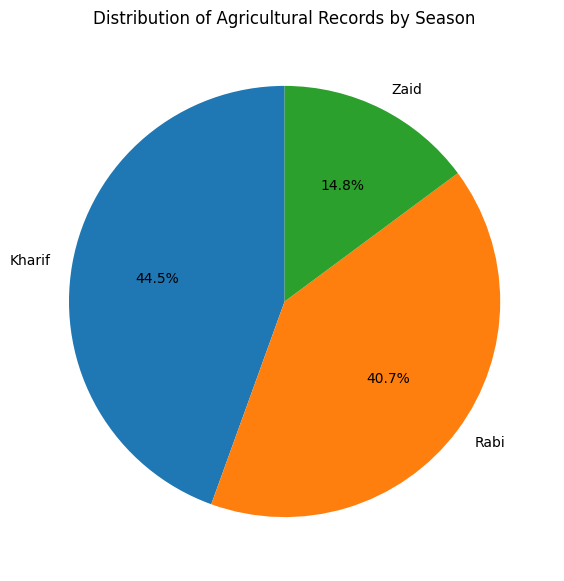

In [64]:
plt.figure(figsize=(7,7))

season_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribution of Agricultural Records by Season')
plt.ylabel('')

plt.show()

This pie chart shows the proportion of agricultural records belonging to kharif, Rabi and Zaid seasons.

#16. UNIVARIATE ANALYSIS: YIELD

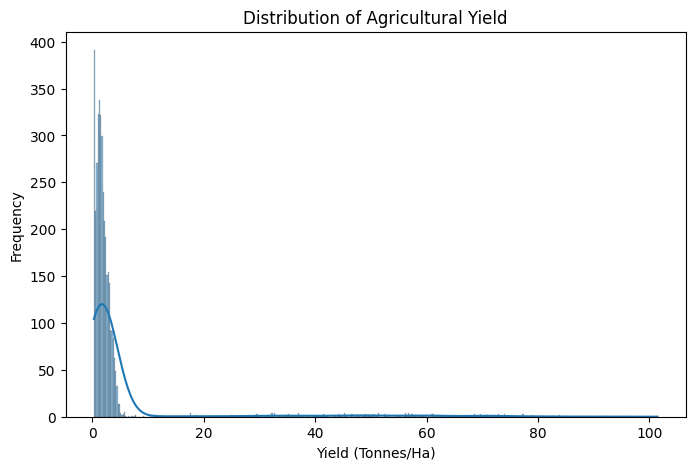

In [65]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Yield_Tonnes_Ha'],
    kde=True
)

plt.title('Distribution of Agricultural Yield')
plt.xlabel('Yield (Tonnes/Ha)')
plt.ylabel('Frequency')

plt.show()

#17. UNIVARIATE ANALYSIS: PROFIT

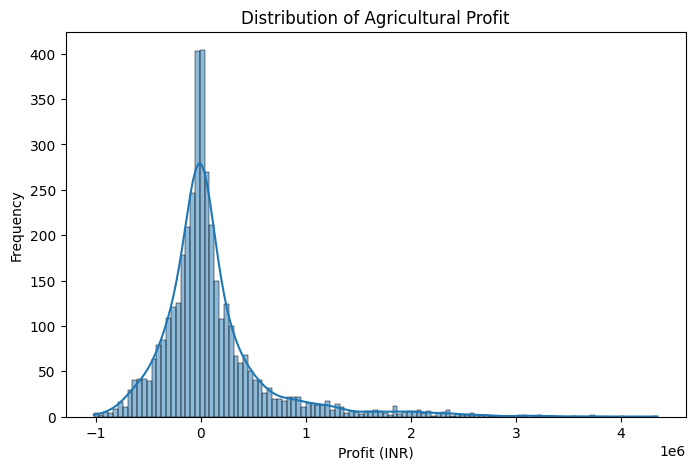

In [66]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Profit_INR'],
    kde=True
)

plt.title('Distribution of Agricultural Profit')
plt.xlabel('Profit (INR)')
plt.ylabel('Frequency')

plt.show()

#18. SEASONAL PERFORMANCE COMPARISON

In [67]:
seasonal_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Revenue_INR': 'mean',
    'Total_Cost_INR': 'mean',
    'Profit_INR': 'mean'
})

display(seasonal_summary.round(2))

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Total_Cost_INR,Profit_INR
Season,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65
Rabi,5.04,41.49,601526.05,513836.58,87689.47
Zaid,4.64,38.89,519171.90,543976.73,-24804.82


#19. SEASONAL YIELD

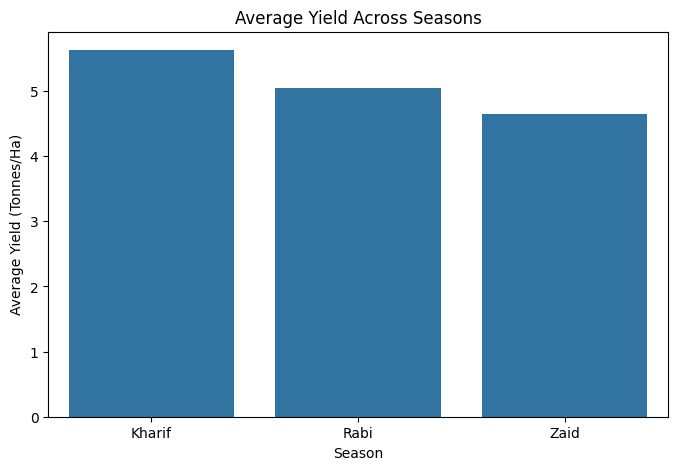

In [68]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    estimator='mean',
    errorbar=None
)

plt.title('Average Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

#20. SEASONAL PRODUCTION

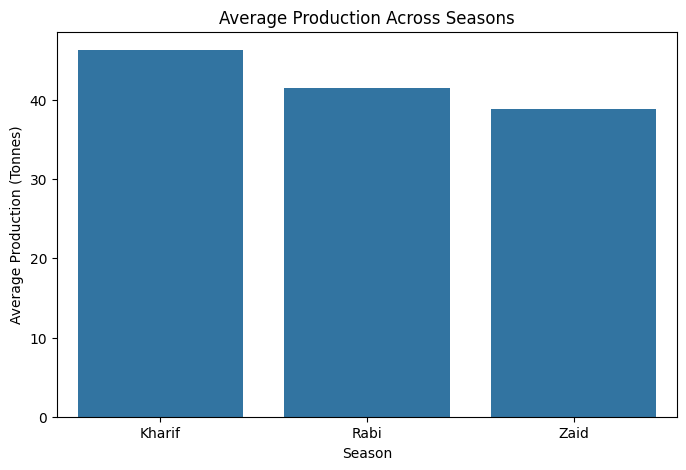

In [69]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Production_Tonnes',
    estimator='mean',
    errorbar=None
)

plt.title('Average Production Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')

plt.show()

#21. SEASONAL PROFIT

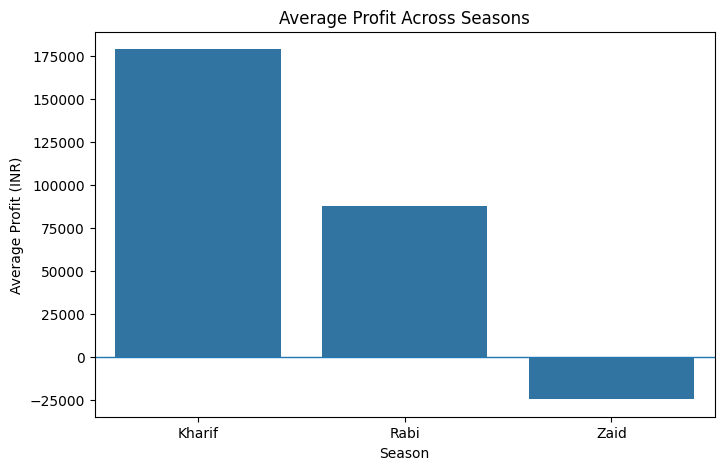

In [70]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Profit_INR',
    estimator='mean',
    errorbar=None
)

plt.axhline(0, linewidth=1)

plt.title('Average Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')

plt.show()

#22. ENVIRONMENTAL CONDITIONS

In [71]:
environmental_summary = df.groupby('Season').agg({
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Sunlight_Hours_Day': 'mean',
    'Soil_Moisture_pct': 'mean'
})

display(environmental_summary.round(2))

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,849.20,28.45,71.81,6.79,31.15
Rabi,437.62,23.49,57.89,7.59,24.07
Zaid,304.65,31.04,52.01,8.18,19.28


#23. ENVIRONMENTAL COMPARISON

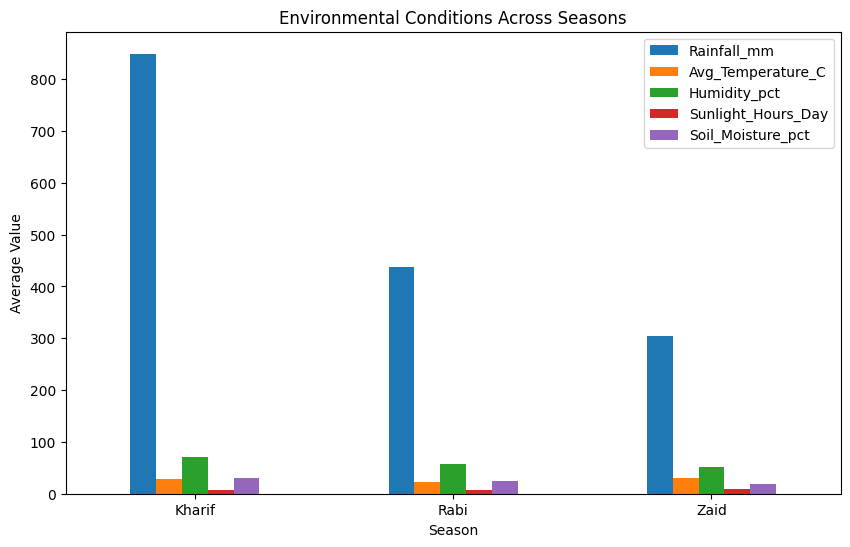

In [72]:
environmental_summary.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Environmental Conditions Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.xticks(rotation=0)

plt.show()

#24. RESOURCE USAGE

In [73]:
resource_summary = df.groupby('Season').agg({
    'Nitrogen_kg_ha': 'mean',
    'Phosphorus_kg_ha': 'mean',
    'Potassium_kg_ha': 'mean',
    'Fertilizer_kg_ha': 'mean',
    'Pesticide_Litre_ha': 'mean',
    'Water_Used_m3': 'mean'
})

display(resource_summary.round(2))

,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Fertilizer_kg_ha,Pesticide_Litre_ha,Water_Used_m3
Season,,,,,,
Kharif,120.02,58.10,105.30,187.08,5.08,6102.20
Rabi,120.40,57.31,103.93,185.41,5.02,5846.99
Zaid,120.53,58.13,105.42,184.64,5.17,6419.89


#25. WATER USAGE

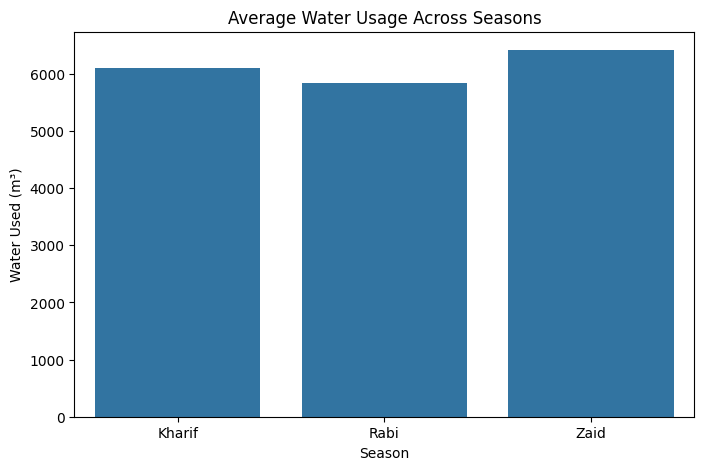

In [74]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Water_Used_m3',
    estimator='mean',
    errorbar=None
)

plt.title('Average Water Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')

plt.show()

#26. WATER EFFICIENCY

In [75]:
water_efficiency = df.groupby('Season')[
    'Water_Efficiency_t_per_1000m3'
].mean()

display(water_efficiency.round(2))

,Water_Efficiency_t_per_1000m3
Season,
Kharif,5.89
Rabi,5.19
Zaid,4.41


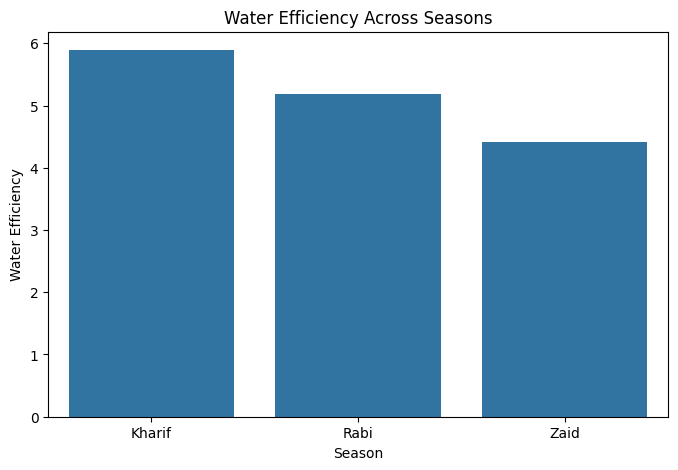

In [76]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Water_Efficiency_t_per_1000m3',
    estimator='mean',
    errorbar=None
)

plt.title('Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Efficiency')

plt.show()

#27. BIVARIATE ANALYSIS

#Rainfall vs Yield

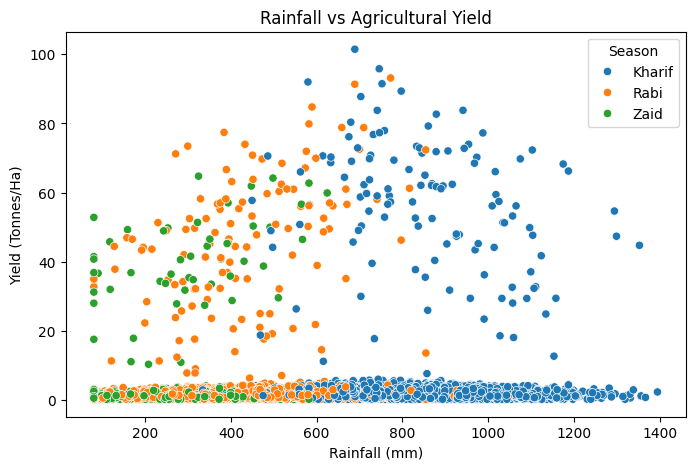

In [77]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Agricultural Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

#28. BIVARIATE ANALYSIS: WATER VS YIELD

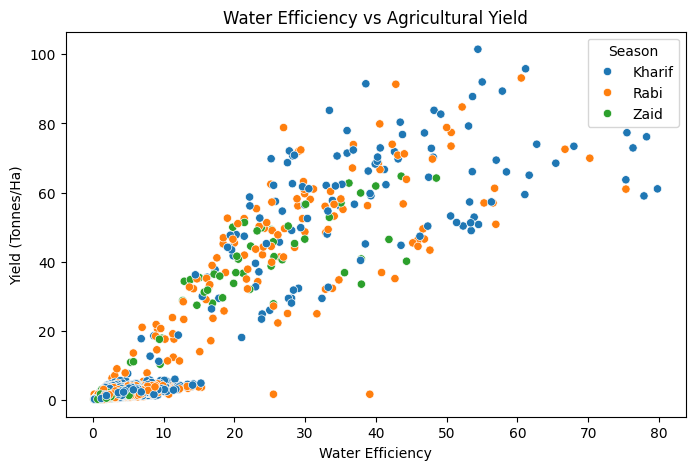

In [78]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Water_Efficiency_t_per_1000m3',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Water Efficiency vs Agricultural Yield')
plt.xlabel('Water Efficiency')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

#29. BIVARIATE ANALYSIS: COST VS PROFIT

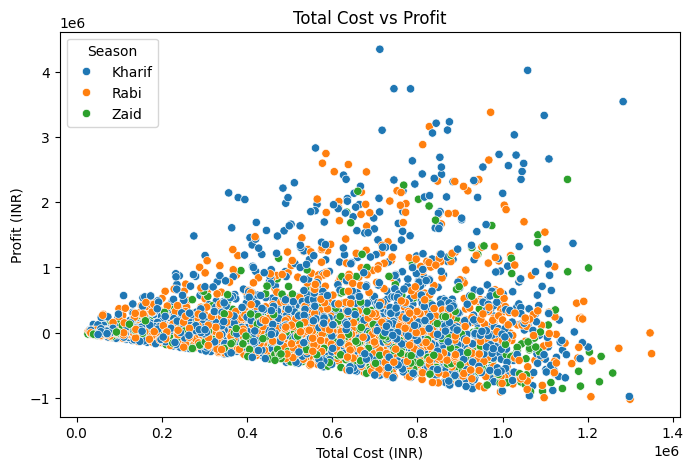

In [79]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Total_Cost_INR',
    y='Profit_INR',
    hue='Season'
)

plt.title('Total Cost vs Profit')
plt.xlabel('Total Cost (INR)')
plt.ylabel('Profit (INR)')

plt.show()

#30. CROP - WISE SEASONAL ANALYSIS

In [80]:
crop_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

display(crop_season_yield.round(2))

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.73,1.47,1.20
Cotton,1.37,1.20,0.96
Groundnut,1.48,1.23,1.04
Maize,2.97,2.60,2.29
Pulses,1.04,0.88,0.67
Rice,2.70,2.32,1.90
Sugarcane,53.46,43.29,38.42
Wheat,2.25,2.06,1.75


#31. MULTIVARIATE ANALYSIS

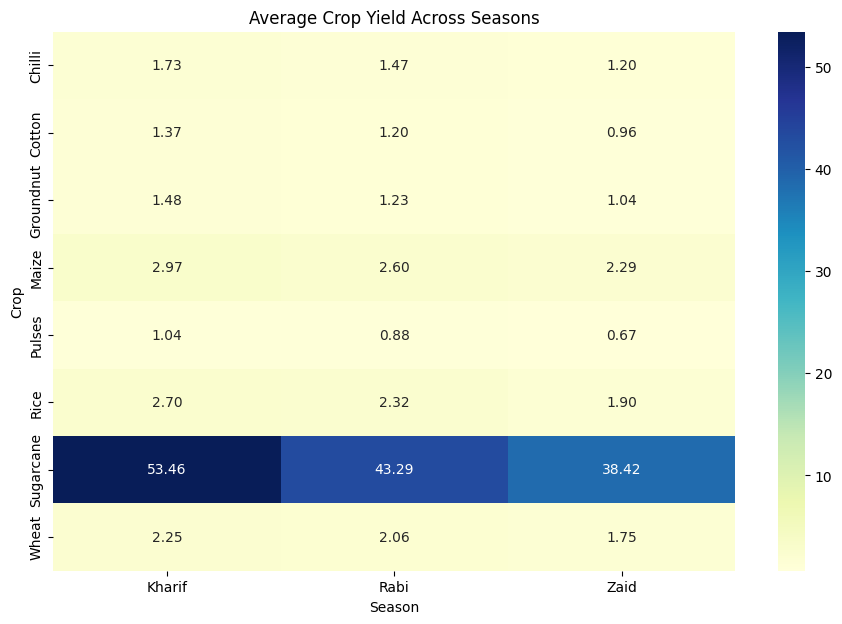

In [81]:
plt.figure(figsize=(11,7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

This is the multivariate analysis, because crop and season are examined together with yield.

#32. IRRIGATION AND SEASONAL PERFORMANCE

In [82]:
irrigation_summary = df.groupby(
    ['Season', 'Irrigation_Method']
).agg({
    'Yield_Tonnes_Ha': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Profit_INR': 'mean'
})

display(irrigation_summary.round(2))

Yield_Tonnes_Ha  Water_Efficiency_t_per_1000m3  \
Season Irrigation_Method                                                   
Kharif Drip                          7.26                           6.80   
       Flood                         4.98                           3.64   
       Rainfed                       5.70                           8.85   
       Sprinkler                     4.66                           4.62   
Rabi   Drip                          6.11                           6.05   
       Flood                         5.06                           3.48   
       Rainfed                       3.93                           6.87   
       Sprinkler                     5.31                           4.64   
Zaid   Drip                          5.85                           5.30   
       Flood                         3.98                           2.73   
       Rainfed                       3.06                           5.48   
       Sprinkler                     6.14                           4.86   

                          Profit_INR  
Season Irrigation_Method              
Kharif Drip                317222.07  
       Flood               133373.83  
       Rainfed             158974.13  
       Sprinkler           116880.49  
Rabi   Drip                187843.22  
       Flood                58824.80  
       Rainfed              45232.48  
       Sprinkler            76502.07  
Zaid   Drip                 21291.84  
       Flood               -69786.78  
       Rainfed             -79467.26  
       Sprinkler            57909.40

#33. IRRIGATION VISUALIZATION

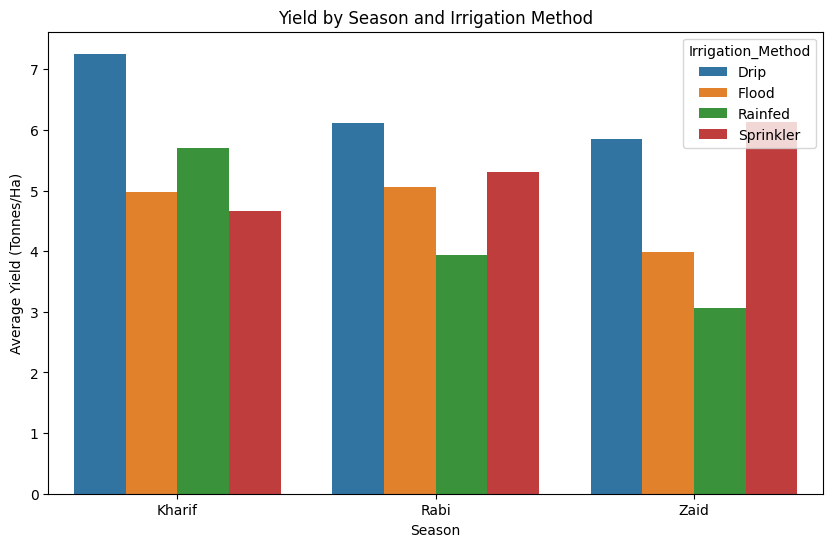

In [83]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha',
    hue='Irrigation_Method',
    estimator='mean',
    errorbar=None
)

plt.title('Yield by Season and Irrigation Method')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')

plt.show()

#34. CORRELATION ANALYSIS

In [84]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

display(correlation_matrix.round(2))

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Farm_Area_Hectares,1.00,0.01,0.04,0.00,0.00,0.01,0.00,0.01,-0.01,0.00,...,0.02,0.03,0.20,-0.02,0.96,0.54,0.12,0.58,0.03,0.03
Rainfall_mm,0.01,1.00,0.20,0.52,-0.36,0.02,0.51,0.01,0.02,0.03,...,-0.02,0.03,0.02,0.00,0.01,0.10,0.11,0.00,0.06,0.62
Avg_Temperature_C,0.04,0.20,1.00,0.14,-0.03,0.03,0.08,0.02,0.01,0.02,...,-0.03,0.01,0.01,0.00,0.04,0.03,0.01,0.02,0.01,0.25
Humidity_pct,0.00,0.52,0.14,1.00,-0.30,0.03,0.45,0.00,-0.01,-0.00,...,-0.05,0.01,0.00,0.00,0.01,0.06,0.06,-0.00,0.03,0.55
Sunlight_Hours_Day,0.00,-0.36,-0.03,-0.30,1.00,-0.02,-0.30,0.01,0.00,-0.01,...,0.02,-0.02,-0.02,-0.00,-0.00,-0.05,-0.05,-0.01,-0.02,-0.25
Soil_pH,0.01,0.02,0.03,0.03,-0.02,1.00,0.03,0.01,0.02,-0.02,...,-0.00,-0.02,-0.01,0.02,0.01,-0.01,-0.01,-0.02,-0.01,0.03
Soil_Moisture_pct,0.00,0.51,0.08,0.45,-0.30,0.03,1.00,0.01,0.01,0.01,...,-0.02,0.01,0.00,0.02,0.00,0.08,0.09,0.00,0.03,0.38
Nitrogen_kg_ha,0.01,0.01,0.02,0.00,0.01,0.01,0.01,1.00,0.01,0.01,...,0.01,0.05,0.05,-0.02,0.01,0.08,0.09,0.02,0.05,-0.01
Phosphorus_kg_ha,-0.01,0.02,0.01,-0.01,0.00,0.02,0.01,0.01,1.00,0.00,...,-0.01,0.05,0.03,-0.01,-0.02,0.03,0.05,-0.00,0.06,0.03
Potassium_kg_ha,0.00,0.03,0.02,-0.00,-0.01,-0.02,0.01,0.01,0.00,1.00,...,0.01,0.00,0.00,0.01,0.00,0.03,0.03,0.00,0.01,0.01


#35. CORRELATION HEATMAP

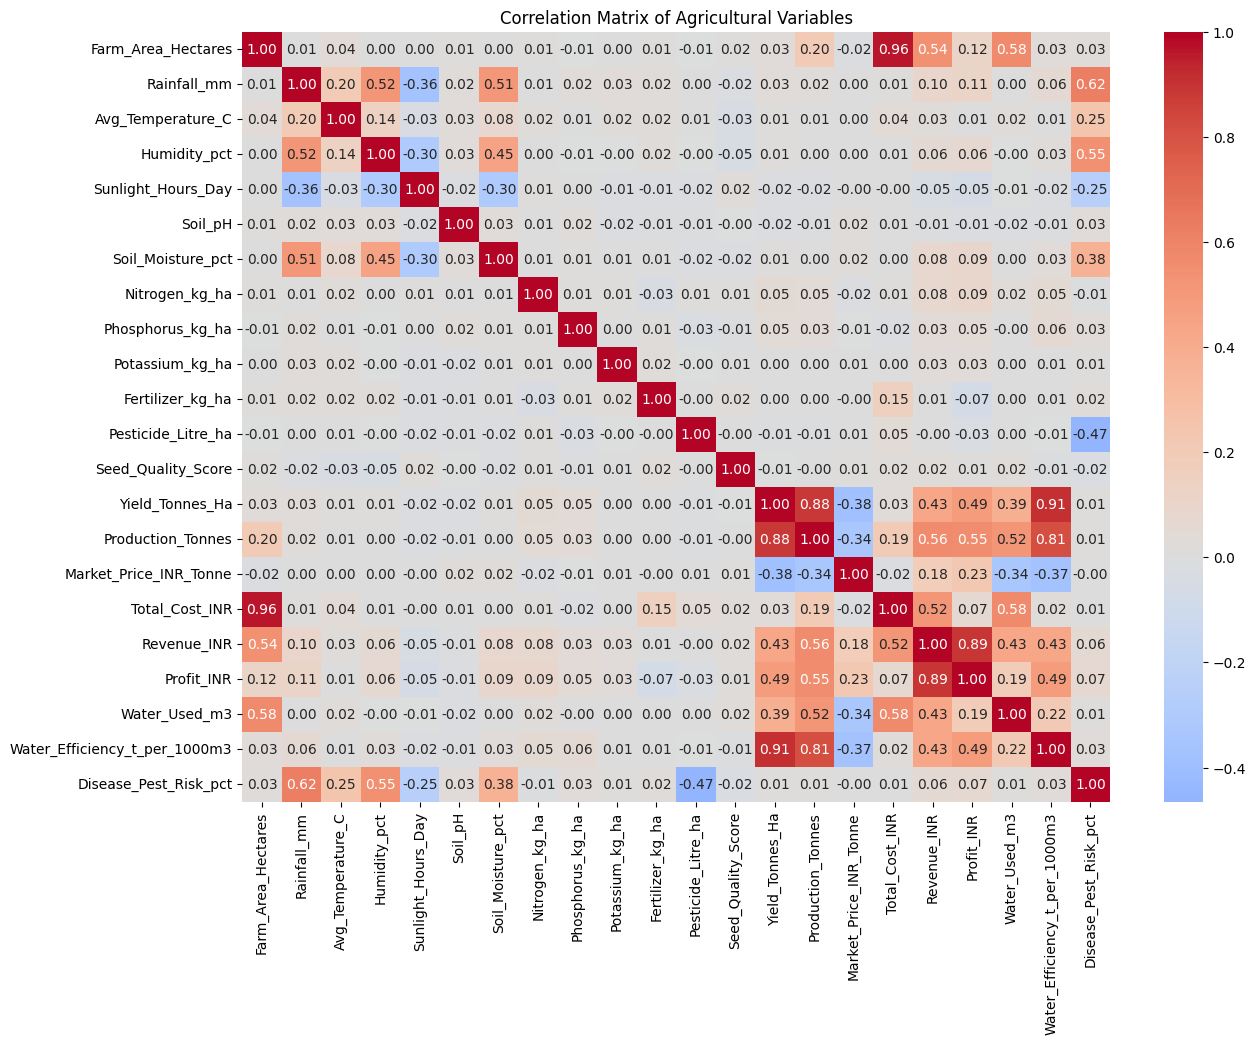

In [85]:
plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Agricultural Variables')

plt.show()

#36. VARIABLES MOST RELATED TO YIELD

In [86]:
yield_correlation = correlation_matrix[
    'Yield_Tonnes_Ha'
].sort_values(ascending=False)

display(yield_correlation.round(3))

,Yield_Tonnes_Ha
Yield_Tonnes_Ha,1.000
Water_Efficiency_t_per_1000m3,0.913
Production_Tonnes,0.883
Profit_INR,0.488
Revenue_INR,0.432
Water_Used_m3,0.386
Nitrogen_kg_ha,0.053
Phosphorus_kg_ha,0.048
Rainfall_mm,0.031
Total_Cost_INR,0.031


#37. STATISTICAL ANALYSIS: ANOVA

We compare the mean yield, profit and water efficiency across seasons.

In [87]:
seasons = df['Season'].dropna().unique()

yield_groups = [
    df[df['Season'] == season]['Yield_Tonnes_Ha']
    for season in seasons
]

profit_groups = [
    df[df['Season'] == season]['Profit_INR']
    for season in seasons
]

water_groups = [
    df[df['Season'] == season][
        'Water_Efficiency_t_per_1000m3'
    ]
    for season in seasons
]

yield_anova = stats.f_oneway(*yield_groups)
profit_anova = stats.f_oneway(*profit_groups)
water_anova = stats.f_oneway(*water_groups)

print("Yield ANOVA")
print("F-statistic:", yield_anova.statistic)
print("p-value:", yield_anova.pvalue)

print("\nProfit ANOVA")
print("F-statistic:", profit_anova.statistic)
print("p-value:", profit_anova.pvalue)

print("\nWater Efficiency ANOVA")
print("F-statistic:", water_anova.statistic)
print("p-value:", water_anova.pvalue)

Yield ANOVA
F-statistic: 1.5438804542488311
p-value: 0.21367813841792296

Profit ANOVA
F-statistic: 34.29175033935195
p-value: 1.7124156677360182e-15

Water Efficiency ANOVA
F-statistic: 6.948269603965189
p-value: 0.0009719376945376617


#38. STATISTICAL INTERPRETATION

In [88]:
alpha = 0.05

print("Statistical Significance Level =", alpha)
print()

if yield_anova.pvalue < alpha:
    print("Yield: Significant difference across seasons.")
else:
    print("Yield: No statistically significant difference across seasons.")

if profit_anova.pvalue < alpha:
    print("Profit: Significant difference across seasons.")
else:
    print("Profit: No statistically significant difference across seasons.")

if water_anova.pvalue < alpha:
    print("Water Efficiency: Significant difference across seasons.")
else:
    print("Water Efficiency: No statistically significant difference across seasons.")

Statistical Significance Level = 0.05

Yield: No statistically significant difference across seasons.
Profit: Significant difference across seasons.
Water Efficiency: Significant difference across seasons.


#39. OUTLIER ANALYSIS

We do not automatically delete outliers.

We investigate them using the IQR method.

In [89]:
outlier_columns = [
    'Yield_Tonnes_Ha',
    'Profit_INR',
    'Water_Used_m3'
]

for column in outlier_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print("\n", column)
    print("Lower limit:", round(lower_limit, 2))
    print("Upper limit:", round(upper_limit, 2))
    print("Number of potential outliers:", len(outliers))


 Yield_Tonnes_Ha
Lower limit: -1.62
Upper limit: 5.5
Number of potential outliers: 302

 Profit_INR
Lower limit: -696111.0
Upper limit: 763567.0
Number of potential outliers: 404

 Water_Used_m3
Lower limit: -6072.75
Upper limit: 16171.25
Number of potential outliers: 276


#40. OUTLIER VISUALIZATION

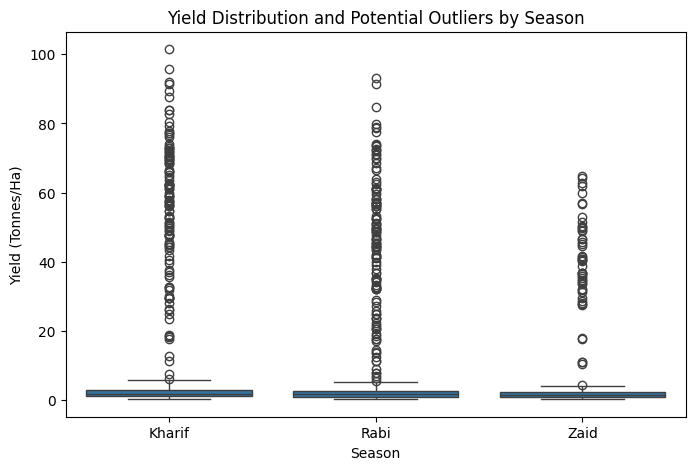

In [90]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Yield_Tonnes_Ha'
)

plt.title('Yield Distribution and Potential Outliers by Season')
plt.xlabel('Season')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

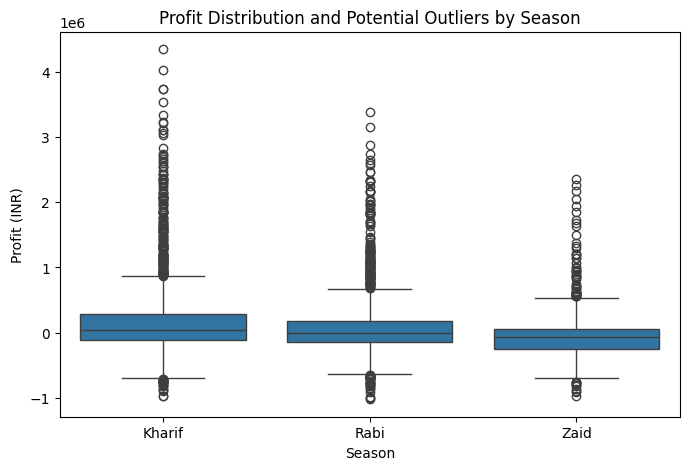

In [91]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Season',
    y='Profit_INR'
)

plt.title('Profit Distribution and Potential Outliers by Season')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')

plt.show()

#Outlier Interpretation



Potential outliers were identified using the IQR method and box plots.

These observations were not automatically removed.

An extreme value may represent:
1. A data-entry problem,
2. A legitimate agricultural observation, or
3. A case requiring further investigation.

Therefore, outliers are retained in the analysis unless there is
evidence that they are incorrect records.

#41. SEASONAL POSITIVE PROFIT

In [92]:
positive_profit = (
    df.assign(Positive_Profit=df['Profit_INR'] > 0)
      .groupby('Season')['Positive_Profit']
      .mean() * 100
)

print("Percentage of records with positive profit:")
display(positive_profit.round(2))

Percentage of records with positive profit:


,Positive_Profit
Season,
Kharif,57.79
Rabi,48.86
Zaid,35.52


#42. SEASONAL DISEASE AND PEST RISK

In [93]:
risk_summary = df.groupby('Season')[
    'Disease_Pest_Risk_pct'
].mean()

display(risk_summary.round(2))

,Disease_Pest_Risk_pct
Season,
Kharif,54.47
Rabi,40.48
Zaid,38.22


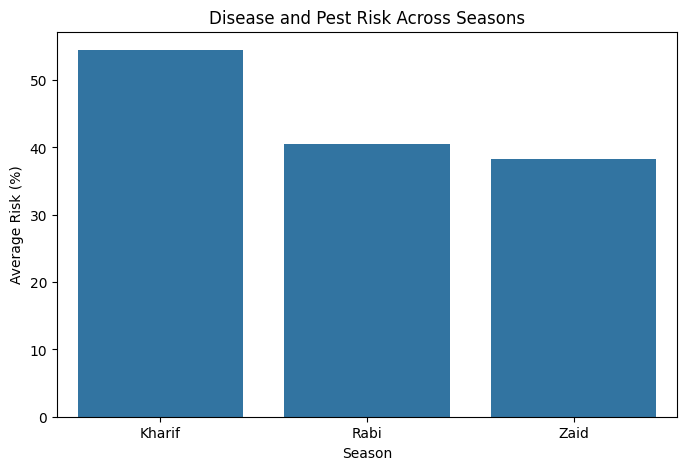

In [94]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x='Season',
    y='Disease_Pest_Risk_pct',
    estimator='mean',
    errorbar=None
)

plt.title('Disease and Pest Risk Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Risk (%)')

plt.show()

#43. AUTOMATIC SEASONAL SUMMARY

In [95]:
summary = df.groupby('Season').agg(
    Average_Yield=('Yield_Tonnes_Ha', 'mean'),
    Average_Production=('Production_Tonnes', 'mean'),
    Average_Revenue=('Revenue_INR', 'mean'),
    Average_Cost=('Total_Cost_INR', 'mean'),
    Average_Profit=('Profit_INR', 'mean'),
    Average_Water=('Water_Used_m3', 'mean'),
    Average_Water_Efficiency=(
        'Water_Efficiency_t_per_1000m3', 'mean'
    ),
    Average_Risk=('Disease_Pest_Risk_pct', 'mean')
)

display(summary.round(2))

,Average_Yield,Average_Production,Average_Revenue,Average_Cost,Average_Profit,Average_Water,Average_Water_Efficiency,Average_Risk
Season,,,,,,,,
Kharif,5.63,46.31,710719.06,531804.41,178914.65,6102.20,5.89,54.47
Rabi,5.04,41.49,601526.05,513836.58,87689.47,5846.99,5.19,40.48
Zaid,4.64,38.89,519171.90,543976.73,-24804.82,6419.89,4.41,38.22


#44. FINAL COMPARISON

In [96]:
best_yield_season = summary['Average_Yield'].idxmax()
best_profit_season = summary['Average_Profit'].idxmax()
best_water_efficiency_season = summary[
    'Average_Water_Efficiency'
].idxmax()

highest_water_season = summary['Average_Water'].idxmax()
highest_risk_season = summary['Average_Risk'].idxmax()

lowest_yield_season = summary['Average_Yield'].idxmin()
lowest_profit_season = summary['Average_Profit'].idxmin()

print("FINAL SEASONAL COMPARISON")
print("=" * 50)

print("Highest average yield:", best_yield_season)
print("Highest average profit:", best_profit_season)
print("Highest water efficiency:", best_water_efficiency_season)
print("Highest water usage:", highest_water_season)
print("Highest disease/pest risk:", highest_risk_season)
print("Lowest average yield:", lowest_yield_season)
print("Lowest average profit:", lowest_profit_season)

FINAL SEASONAL COMPARISON
Highest average yield: Kharif
Highest average profit: Kharif
Highest water efficiency: Kharif
Highest water usage: Zaid
Highest disease/pest risk: Kharif
Lowest average yield: Zaid
Lowest average profit: Zaid


#45.EIGHT KEY INSIGHTS

The following cell generates the findings from the actual dataset rather than manually inserting unsupported numbers.

In [97]:
# Values calculated directly from the cleaned dataset

yield_rank = summary['Average_Yield'].sort_values(ascending=False)
profit_rank = summary['Average_Profit'].sort_values(ascending=False)
water_rank = summary['Average_Water'].sort_values(ascending=False)
efficiency_rank = summary[
    'Average_Water_Efficiency'
].sort_values(ascending=False)
risk_rank = summary['Average_Risk'].sort_values(ascending=False)

print("INSIGHT 1: SEASONAL YIELD")
print("-" * 60)
print(f"Observation: {yield_rank.index[0]} has the highest average yield.")
print(f"Evidence: Average yield = {yield_rank.iloc[0]:.2f} tonnes/ha.")
print("Interpretation: Agricultural yield varies across seasons.")
print("Limitation: The analysis shows seasonal association, not causation.")
print()

print("INSIGHT 2: SEASONAL PROFIT")
print("-" * 60)
print(f"Observation: {profit_rank.index[0]} has the highest average profit.")
print(f"Evidence: Average profit = ₹{profit_rank.iloc[0]:,.2f}.")
print("Interpretation: Economic performance differs across seasons.")
print("Limitation: Profit is also influenced by several other variables.")
print()

print("INSIGHT 3: LOWEST PROFIT")
print("-" * 60)
print(f"Observation: {profit_rank.index[-1]} has the lowest average profit.")
print(f"Evidence: Average profit = ₹{profit_rank.iloc[-1]:,.2f}.")
print("Interpretation: This season shows comparatively weaker economic performance.")
print("Limitation: This does not mean every farm in the season is unprofitable.")
print()

print("INSIGHT 4: WATER USAGE")
print("-" * 60)
print(f"Observation: {water_rank.index[0]} has the highest average water usage.")
print(f"Evidence: Average water usage = {water_rank.iloc[0]:,.2f} m³.")
print("Interpretation: Water requirements differ across seasons.")
print("Limitation: Water usage can depend on crop and farming practices.")
print()

print("INSIGHT 5: WATER EFFICIENCY")
print("-" * 60)
print(f"Observation: {efficiency_rank.index[0]} has the highest water efficiency.")
print(f"Evidence: Average water efficiency = {efficiency_rank.iloc[0]:.2f}.")
print("Interpretation: Resource-use efficiency varies across seasons.")
print("Limitation: Correlation or seasonal comparison alone cannot establish causation.")
print()

print("INSIGHT 6: DISEASE AND PEST RISK")
print("-" * 60)
print(f"Observation: {risk_rank.index[0]} has the highest average disease/pest risk.")
print(f"Evidence: Average risk = {risk_rank.iloc[0]:.2f}%.")
print("Interpretation: Disease and pest risk varies by season.")
print("Limitation: The dataset does not establish the specific cause of the risk difference.")
print()

print("INSIGHT 7: YIELD AND WATER EFFICIENCY")
print("-" * 60)

yield_water_corr = df[
    ['Yield_Tonnes_Ha', 'Water_Efficiency_t_per_1000m3']
].corr().iloc[0,1]

print(f"Observation: Yield and water efficiency show a correlation of {yield_water_corr:.3f}.")
print("Evidence: Pearson correlation analysis was performed.")
print("Interpretation: The variables have an association in the dataset.")
print("Limitation: Correlation does not prove that one variable causes the other.")
print()

print("INSIGHT 8: STATISTICAL SEASONAL DIFFERENCES")
print("-" * 60)
print(f"Observation: Profit ANOVA p-value = {profit_anova.pvalue:.6f}.")
print("Evidence: One-way ANOVA was used to compare seasonal means.")
print("Interpretation: The result indicates whether observed seasonal profit differences")
print("are statistically significant at the 5% significance level.")
print("Limitation: Statistical significance does not explain the underlying cause.")

INSIGHT 1: SEASONAL YIELD
------------------------------------------------------------
Observation: Kharif has the highest average yield.
Evidence: Average yield = 5.63 tonnes/ha.
Interpretation: Agricultural yield varies across seasons.
Limitation: The analysis shows seasonal association, not causation.

INSIGHT 2: SEASONAL PROFIT
------------------------------------------------------------
Observation: Kharif has the highest average profit.
Evidence: Average profit = ₹178,914.65.
Interpretation: Economic performance differs across seasons.
Limitation: Profit is also influenced by several other variables.

INSIGHT 3: LOWEST PROFIT
------------------------------------------------------------
Observation: Zaid has the lowest average profit.
Evidence: Average profit = ₹-24,804.82.
Interpretation: This season shows comparatively weaker economic performance.
Limitation: This does not mean every farm in the season is unprofitable.

INSIGHT 4: WATER USAGE
------------------------------------

#46. RECOMMENDATIONS


1. Seasonal planning should consider the observed differences in yield,
   production and profitability.

2. Water management should receive particular attention in seasons with
   comparatively high water usage and lower water efficiency.

3. Agricultural planning should consider crop performance separately
   across seasons because crop yield varies by season.

4. Irrigation practices should be evaluated together with seasonal
   conditions and crop requirements.

5. Seasons showing higher disease and pest risk should receive closer
   monitoring and further investigation.

6. Production costs and revenue should be considered together when
   evaluating seasonal economic performance.

7. Potential outliers should be investigated individually before being
   removed or treated as errors.

8. The observed relationships can be used as a basis for further
   agricultural investigation, but causal conclusions should not be
   made from this analysis alone.

#47. FINAL CONCLUSION

# Conclusion

The Seasonal Agriculture Performance Analysis examined agricultural
records across different seasons using environmental, resource,
production and economic variables.

The analysis revealed differences in agricultural performance across
seasons, including variations in yield, production, water usage,
water efficiency, disease/pest risk and profitability.

Univariate analysis was used to understand individual variables.
Bivariate analysis examined relationships between important variables.
Multivariate analysis compared agricultural performance across crops
and seasons.

Correlation analysis identified associations between relevant
agricultural variables, while statistical analysis was used to examine
seasonal differences.

Potential outliers were investigated using statistical and visual
methods without automatically removing them.

The findings provide evidence-based insights into seasonal agricultural
performance and can support further investigation and better seasonal
planning.

However, the analysis is based only on the available dataset.
Observed relationships should not be interpreted as proof of causation,
and additional data would be required for stronger conclusions.

#48. PROJECT CHECKLIST

In [98]:
checklist = {
    "Dataset loaded successfully": True,
    "Top 5 rows analyzed": True,
    "Dataset shape examined": True,
    "Dataset structure examined": True,
    "Data types examined": True,
    "Missing values identified and handled": True,
    "Duplicate records identified and handled": True,
    "Descriptive/statistical analysis performed": True,
    "Outliers investigated": True,
    "Univariate analysis completed": True,
    "Season distribution pie chart completed": True,
    "Bivariate analysis completed": True,
    "Multivariate analysis completed": True,
    "Correlation analysis completed": True,
    "Seasonal comparisons performed": True,
    "8 evidence-based insights provided": True,
    "Recommendations provided": True,
    "Conclusion provided": True
}

checklist_df = pd.DataFrame(
    list(checklist.items()),
    columns=["Requirement", "Completed"]
)

display(checklist_df)

,Requirement,Completed
0,Dataset loaded successfully,True
1,Top 5 rows analyzed,True
2,Dataset shape examined,True
3,Dataset structure examined,True
4,Data types examined,True
5,Missing values identified and handled,True
6,Duplicate records identified and handled,True
7,Descriptive/statistical analysis performed,True
8,Outliers investigated,True
9,Univariate analysis completed,True
